# Beyond Discounts: Retail Sales & Profit Analysis

## Overview

This project explores a retail sales dataset to understand how sales, discounts, and profit are related. The analysis focuses on identifying patterns in profitability across product categories and discount levels.

The goal is to use exploratory data analysis (EDA) to uncover business insights that could help a retailer understand where profit is being generated and where losses may occur.

## Business Question

How are discounts related to profitability and which product categories generate the most profit?

### Questions explored
- Which product category generates the most sales?
- Which category generates the most profit?
- How does discount level relate to profit?
- How many transactions result in a loss?
- Are there noticeable changes in sales and profit over time?

In [44]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore (1).csv


In [ ]:
df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
df.shape

(9994, 21)

In [ ]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [ ]:
df['Category'].unique()

array(['Furniture', 'Office Supplies', 'Technology'], dtype=object)

In [ ]:
df.groupby('Category')['Sales'].sum()

,Sales
Category,
Furniture,741999.7953
Office Supplies,719047.0320
Technology,836154.0330


In [ ]:
df.groupby('Category')['Profit'].sum()

,Profit
Category,
Furniture,18451.2728
Office Supplies,122490.8008
Technology,145454.9481


In [ ]:
df.groupby('Category')['Discount'].mean()

,Discount
Category,
Furniture,0.173923
Office Supplies,0.157285
Technology,0.132323


In [ ]:
df.groupby('Category')[['Discount', 'Profit']].mean()

,Discount,Profit
Category,,
Furniture,0.173923,8.699327
Office Supplies,0.157285,20.327050
Technology,0.132323,78.752002


# Visualizations

The scatter plot below explores the relationship between discount levels and profit.

In [39]:
import matplotlib.pyplot as plt

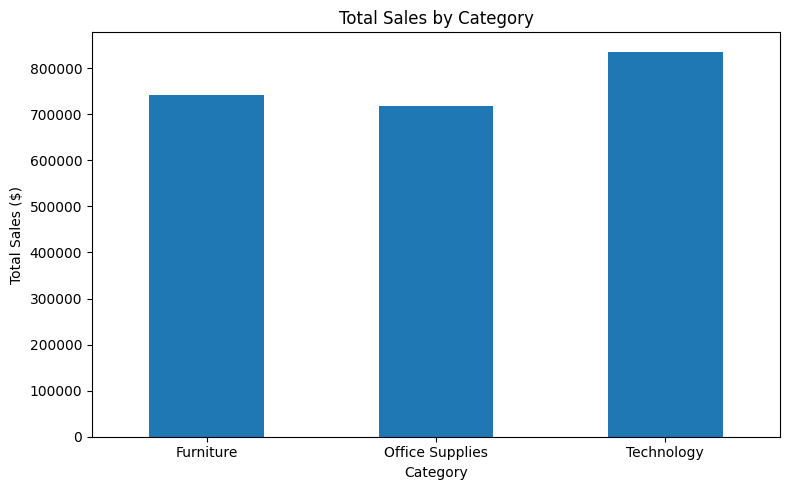

In [40]:
# Sales by Category

sales_by_category = df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(8, 5))
sales_by_category.plot(kind='bar')

plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Insight: Sales by Category

Technology generated the highest total sales among the three product categories, followed by Furniture and Office Supplies. This shows that Technology contributed the largest share of sales in the dataset.

<Axes: xlabel='Discount', ylabel='Profit'>

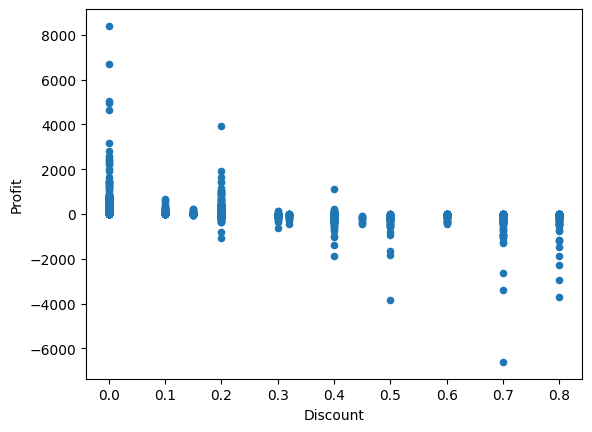

In [ ]:
df.plot.scatter(x='Discount', y='Profit')

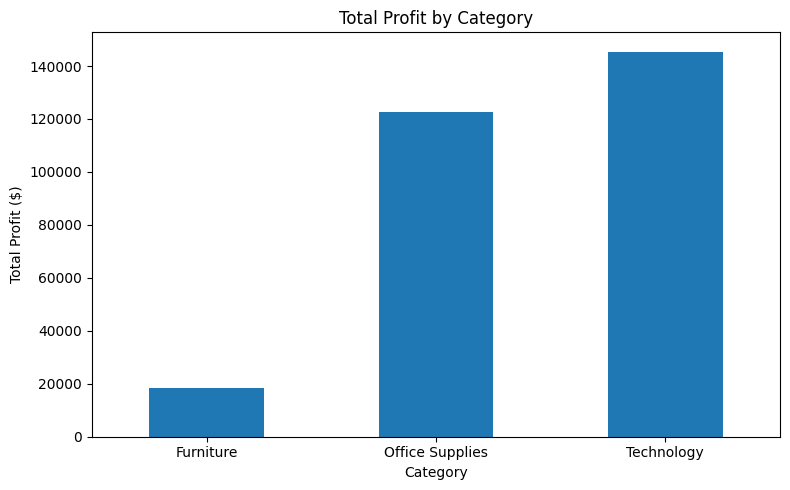

In [41]:
# Profit by Category

profit_by_category = df.groupby('Category')['Profit'].sum()

plt.figure(figsize=(8, 5))
profit_by_category.plot(kind='bar')

plt.title('Total Profit by Category')
plt.xlabel('Category')
plt.ylabel('Total Profit ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Insight: Profit by Category

Technology generated the highest total profit, followed by Office Supplies. Furniture generated substantially less profit than the other two categories despite its considerable sales volume.

This suggests that high sales do not necessarily translate into high profitability.

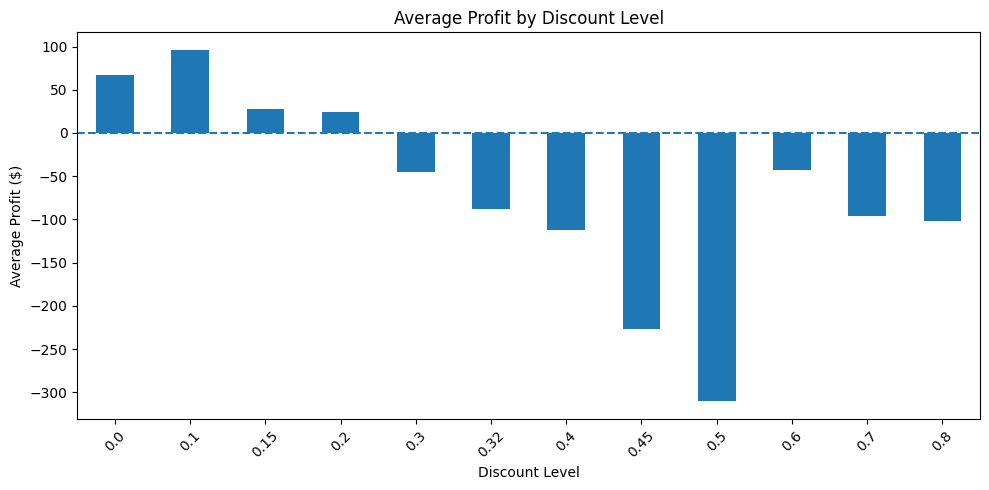

In [42]:
# Average Profit by Discount Level

profit_by_discount = df.groupby('Discount')['Profit'].mean()

plt.figure(figsize=(10, 5))
profit_by_discount.plot(kind='bar')

plt.title('Average Profit by Discount Level')
plt.xlabel('Discount Level')
plt.ylabel('Average Profit ($)')
plt.xticks(rotation=45)
plt.axhline(y=0, linestyle='--')
plt.tight_layout()
plt.show()

### Insight: Average Profit by Discount Level

The chart shows that average profit generally decreases at higher discount levels. Average profit becomes negative at several higher discount levels, particularly around 30% and above.

This suggests that large discounts may be associated with reduced profitability. However, discounting alone does not establish the cause of the losses.

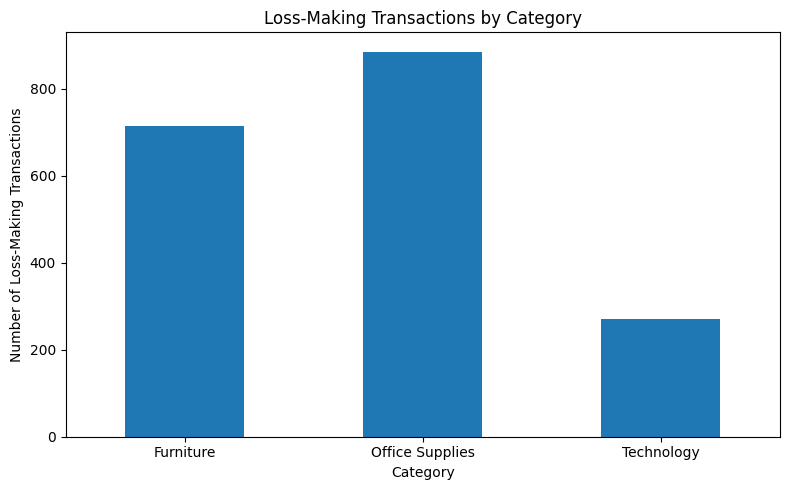

In [43]:
# Loss-Making Transactions by Category

loss_transactions = df[df['Profit'] < 0]

losses_by_category = loss_transactions.groupby('Category').size()

plt.figure(figsize=(8, 5))
losses_by_category.plot(kind='bar')

plt.title('Loss-Making Transactions by Category')
plt.xlabel('Category')
plt.ylabel('Number of Loss-Making Transactions')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Insight: Loss-Making Transactions by Category

Office Supplies recorded the highest number of loss-making transactions, followed by Furniture and Technology.

This indicates that losses occurred across all three categories. Further analysis of individual products and sub-categories could help identify the specific areas contributing to these losses.

In [ ]:
df['Discount'].corr(df['Profit'])

np.float64(-0.21948745637176803)

In [ ]:
df.groupby('Discount')['Profit'].mean().sort_index()

,Profit
Discount,
0.00,66.900292
0.10,96.055074
0.15,27.288298
0.20,24.702572
0.30,-45.679636
0.32,-88.560656
0.40,-111.927429
0.45,-226.646464
0.50,-310.703456


In [ ]:
df[df['Profit'] < 0].shape

(1871, 21)

In [ ]:
(df['Profit'] < 0).mean() * 100

np.float64(18.721232739643785)

In [ ]:
df[df['Profit'] < 0].groupby('Category')['Profit'].count()

,Profit
Category,
Furniture,714
Office Supplies,886
Technology,271


In [ ]:
(df['Profit'] < 0).groupby(df['Category']).mean() * 100

,Profit
Category,
Furniture,33.663366
Office Supplies,14.702954
Technology,14.672442


In [ ]:
df.nsmallest(10, 'Profit')[['Product Name', 'Category', 'Discount', 'Sales', 'Profit']]

,Product Name,Category,Discount,Sales,Profit
7772,Cubify CubeX 3D Printer Double Head Print,Technology,0.7,4499.985,-6599.9780
683,Cubify CubeX 3D Printer Triple Head Print,Technology,0.5,7999.980,-3839.9904
9774,GBC DocuBind P400 Electric Binding System,Office Supplies,0.8,2177.584,-3701.8928
3011,Lexmark MX611dhe Monochrome Laser Printer,Technology,0.7,2549.985,-3399.9800
4991,Ibico EPK-21 Electric Binding System,Office Supplies,0.8,1889.990,-2929.4845
3151,Cubify CubeX 3D Printer Double Head Print,Technology,0.7,1799.994,-2639.9912
5310,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,0.8,1525.188,-2287.7820
9639,Chromcraft Bull-Nose Wood Oval Conference Tabl...,Furniture,0.4,4297.644,-1862.3124
1199,GBC DocuBind P400 Electric Binding System,Office Supplies,0.8,1088.792,-1850.9464
2697,Cisco TelePresence System EX90 Videoconferenci...,Technology,0.5,22638.480,-1811.0784


In [ ]:
df[df['Profit'] < 0].groupby('Sub-Category')['Profit'].count().sort_values(ascending=False)

,Profit
Sub-Category,
Binders,613
Chairs,235
Tables,203
Furnishings,167
Storage,161
Phones,136
Bookcases,109
Accessories,91
Appliances,67


In [ ]:
df['Sales'].corr(df['Profit'])

np.float64(0.4790643497377062)

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [ ]:
df['Order Date'].min(), df['Order Date'].max()

(Timestamp('2014-01-03 00:00:00'), Timestamp('2017-12-30 00:00:00'))

In [ ]:
df['Year'] = df['Order Date'].dt.year

df.groupby('Year')[['Sales', 'Profit']].sum()

,Sales,Profit
Year,,
2014,484247.4981,49543.9741
2015,470532.5090,61618.6037
2016,609205.5980,81795.1743
2017,733215.2552,93439.2696


# Key Findings

1. Technology generated the highest total profit at approximately $145,455, followed by Office Supplies at approximately $122,491 and Furniture at approximately $18,451.

2. Furniture generated substantial sales of approximately $742,000 but had comparatively low profitability.

3. Furniture had the highest average discount at approximately 17.4%, while Technology had the lowest at approximately 13.2%.

4. Discount and profit had a correlation of approximately -0.22, indicating a weak negative relationship.

5. Average profit became negative at higher discount levels, particularly around 30% discount and above.

6. 1,871 out of 9,994 transactions were loss-making, representing approximately 18.72% of all transactions.

7. The analysis suggests that higher discounts are associated with lower profitability, although discounting alone does not explain all differences in profit.

# Conclusion

This exploratory data analysis examined the relationship between sales, discounts, and profit in a retail dataset.

The analysis suggests that higher discount levels are associated with lower profitability, particularly at higher discount levels. However, the relatively weak overall correlation indicates that other factors also influence profit.

Category-level analysis showed that Technology generated substantially more profit than Furniture despite having a lower average discount. Furniture, on the other hand, combined relatively high discounts with comparatively low profitability.

Approximately 18.72% of transactions were loss-making, showing that profitability challenges were present across a meaningful portion of the dataset.

Overall, the analysis demonstrates how exploratory data analysis can be used to identify patterns in sales and profitability. Further analysis of individual products and sub-categories could provide more detailed insight into where losses are concentrated.




# Business Recommendations

Based on the findings, the following recommendations could help improve profitability:

1. **Review high discount levels:** The business should carefully evaluate discounts of 30% and above, as these levels were associated with negative average profit in the dataset.

2. **Use targeted discounting:** Instead of applying large discounts broadly, discounts could be targeted toward products or customer segments where they are more likely to generate profitable sales.

3. **Review Furniture pricing and costs:** Furniture generated substantial sales but relatively low profit. The business should investigate its pricing, discounts, product costs, and individual products within this category.

4. **Protect profitable categories:** Technology generated the highest total profit while having the lowest average discount among the three categories. The business should examine the factors contributing to this performance and avoid unnecessary discounting of profitable products.

5. **Investigate loss-making transactions:** Since approximately 18.72% of transactions resulted in a loss, the business should identify the specific products, sub-categories, and discount levels contributing most to these losses.

6. **Use data to guide pricing decisions:** Future pricing and discount decisions should be based on profitability analysis rather than sales volume alone, since high sales do not necessarily result in high profit.
